<a href="https://colab.research.google.com/github/antonellagambarte/vision-por-computadoras-II/blob/main/entrega%20final/%20modelos_basicos_con_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Optimizado para Clasificación de Enfermedades en Plantas

Este notebook mejora el pipeline anterior con las siguientes optimizaciones:

1. **Eliminación de imágenes duplicadas**: Detectamos y removemos imágenes duplicadas usando hashing perceptual para evitar sesgos en el entrenamiento
2. **Data Augmentation en clases subrepresentadas**: Aplicamos aumento de datos específicamente en las clases con menor representación para balancear el dataset

**Modelos a comparar:**
- MobileNetV2
- MobileNetV3

**Objetivo**: Maximizar recall y accuracy mientras mantenemos el modelo lo suficientemente ligero para deployment móvil.


In [ ]:
test_execution = False


## Imports y Configuración Inicial


In [ ]:
import gdown
import zipfile
import os
import time
import copy
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                            f1_score, roc_curve, auc, precision_recall_curve,
                            average_precision_score)
from sklearn.preprocessing import LabelBinarizer

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx

import warnings

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Para asegurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Silenciar warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


Usando dispositivo: cuda


## Carga del Dataset


In [ ]:
url = "https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri"
output = "archivo.zip"
destino = "datos_zip"

def zip_is_valid(path):
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except Exception as e:
        print("Error:", e)
        return False

# Descargar solo si no existe o si el zip es inválido
if not zip_is_valid(output):
    print("Descargando dataset...")
    gdown.download(url, output, quiet=False, fuzzy=True)
else:
    print(f"'{output}' ya existe.")

os.makedirs(destino, exist_ok=True)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

print("Archivo extraído correctamente en:", destino)


Descargando dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri
From (redirected): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri&confirm=t&uuid=9b681d47-dd29-4e27-b9f7-151f2615f9a6
To: /content/archivo.zip
100%|██████████| 2.19G/2.19G [00:42<00:00, 51.6MB/s]


Archivo extraído correctamente en: datos_zip


## 1. Detección y Eliminación de Duplicados

Utilizamos hash para detectar imágenes duplicadas.
Esto previene que el modelo memorice la misma imagen y mejora la generalización.


In [ ]:
def compute_file_hash(image_path, algo="md5", chunk_size=8192):
    """
    Calcula un hash exacto del archivo de imagen.
    Esto detecta imágenes idénticas (bit a bit).
    """
    hash_func = hashlib.md5() if algo == "md5" else hashlib.sha256()

    try:
        with open(image_path, "rb") as f:
            while chunk := f.read(chunk_size):
                hash_func.update(chunk)
        return hash_func.hexdigest()
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return None

def find_duplicate_images(data_dir, algo="md5"):
    """
    Encuentra imágenes duplicadas exactas (mismo contenido).
    Retorna dict {hash: [paths]} donde paths > 1 son duplicados.
    """
    hash_dict = defaultdict(list)

    print("Calculando hashes exactos...")
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc=f"Procesando {os.path.basename(root)}"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                img_hash = compute_file_hash(file_path, algo)

                if img_hash:
                    hash_dict[img_hash].append(file_path)

    # Filtrar solo duplicados
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    return duplicates


def remove_duplicates(data_dir, duplicates_dict):
    """
    Elimina imágenes duplicadas, manteniendo solo una copia de cada grupo.
    """
    removed_count = 0

    for img_hash, paths in duplicates_dict.items():
        # Mantener la primera imagen, eliminar el resto
        for path_to_remove in paths[1:]:
            try:
                os.remove(path_to_remove)
                removed_count += 1
            except Exception as e:
                print(f"Error eliminando {path_to_remove}: {e}")

    return removed_count


In [ ]:
# Ejecutar detección y eliminación de duplicados
data_dir = "datos_zip/plantvillage dataset/color"

print("="*70)
print("PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS")
print("="*70)

duplicates = find_duplicate_images(data_dir)

if duplicates:
    print(f"\n📊 Se encontraron {len(duplicates)} grupos de imágenes duplicadas")
    print(f"   Total de imágenes duplicadas: {sum(len(paths)-1 for paths in duplicates.values())}")

    # Mostrar algunos ejemplos
    print("\n📋 Primeros 5 grupos de duplicados:")
    for i, (img_hash, paths) in enumerate(list(duplicates.items())[:5]):
        print(f"  Grupo {i+1}: {len(paths)} copias")
        for path in paths[:3]:  # Mostrar max 3 paths
            print(f"    - {path}")

    # Eliminar duplicados
    print("\n🗑️ Eliminando duplicados...")
    removed = remove_duplicates(data_dir, duplicates)
    print(f"✅ Se eliminaron {removed} imágenes duplicadas")
else:
    print("✅ No se encontraron duplicados en el dataset")


PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS
Calculando hashes exactos...


Procesando color: 0it [00:00, ?it/s]
Procesando Soybean___healthy: 100%|██████████| 5090/5090 [00:00<00:00, 13193.41it/s]
Procesando Cherry_(including_sour)___Powdery_mildew: 100%|██████████| 1052/1052 [00:00<00:00, 12799.09it/s]
Procesando Grape___Esca_(Black_Measles): 100%|██████████| 1383/1383 [00:00<00:00, 15345.06it/s]
Procesando Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 5507/5507 [00:00<00:00, 23453.11it/s]
Procesando Corn_(maize)___Common_rust_: 100%|██████████| 1192/1192 [00:00<00:00, 21115.09it/s]
Procesando Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████| 5357/5357 [00:00<00:00, 21195.04it/s]
Procesando Strawberry___Leaf_scorch: 100%|██████████| 1109/1109 [00:00<00:00, 17386.51it/s]
Procesando Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1676/1676 [00:00<00:00, 7825.05it/s] 
Procesando Potato___Early_blight: 100%|██████████| 1000/1000 [00:00<00:00, 16741.26it/s]
Procesando Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100%|██████████|


📊 Se encontraron 21 grupos de imágenes duplicadas
   Total de imágenes duplicadas: 21

📋 Primeros 5 grupos de duplicados:
  Grupo 1: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/5688ea99-c949-41d0-bbab-9cbf0ffb8bcd___GHLB2 Leaf 8677.JPG
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 Leaf 8677.JPG
  Grupo 2: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/2c47b891-3c97-48f1-a2cc-5aa53d3a1148___GHLB2 Leaf 9011.JPG
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/1a69b38b-c4eb-42c4-9584-bcb14fb8db0c___GHLB2 Leaf 9011.JPG
  Grupo 3: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/861d8b00-57a4-46b0-b51a-09d102dbe119___GHLB_PS Leaf 24 Day 13.jpg
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/d82b634e-9a19-497b-b698-aaf100d622a1___GHLB_PS Leaf 24 Day 13.jpg
  Grupo 4: 2 copias
    - datos_zip/plantvillage dataset/color/To

## 2. Análisis de Distribución de Clases

Analizamos cuántas imágenes tiene cada clase para identificar desbalance.


PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES

📊 Dataset Statistics:
   Total de clases: 38
   Total de imágenes: 54284
   Promedio por clase: 1428.5

📉 Top 10 clases con MENOS imágenes:
   Potato___healthy                                  :   152 imágenes (0.28%)
   Apple___Cedar_apple_rust                          :   275 imágenes (0.51%)
   Peach___healthy                                   :   360 imágenes (0.66%)
   Raspberry___healthy                               :   371 imágenes (0.68%)
   Tomato___Tomato_mosaic_virus                      :   373 imágenes (0.69%)
   Grape___healthy                                   :   423 imágenes (0.78%)
   Strawberry___healthy                              :   456 imágenes (0.84%)
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 imágenes (0.95%)
   Apple___Black_rot                                 :   621 imágenes (1.14%)
   Apple___Apple_scab                                :   630 imágenes (1.16%)

📈 Top 10 clases con MÁS imágenes:
 

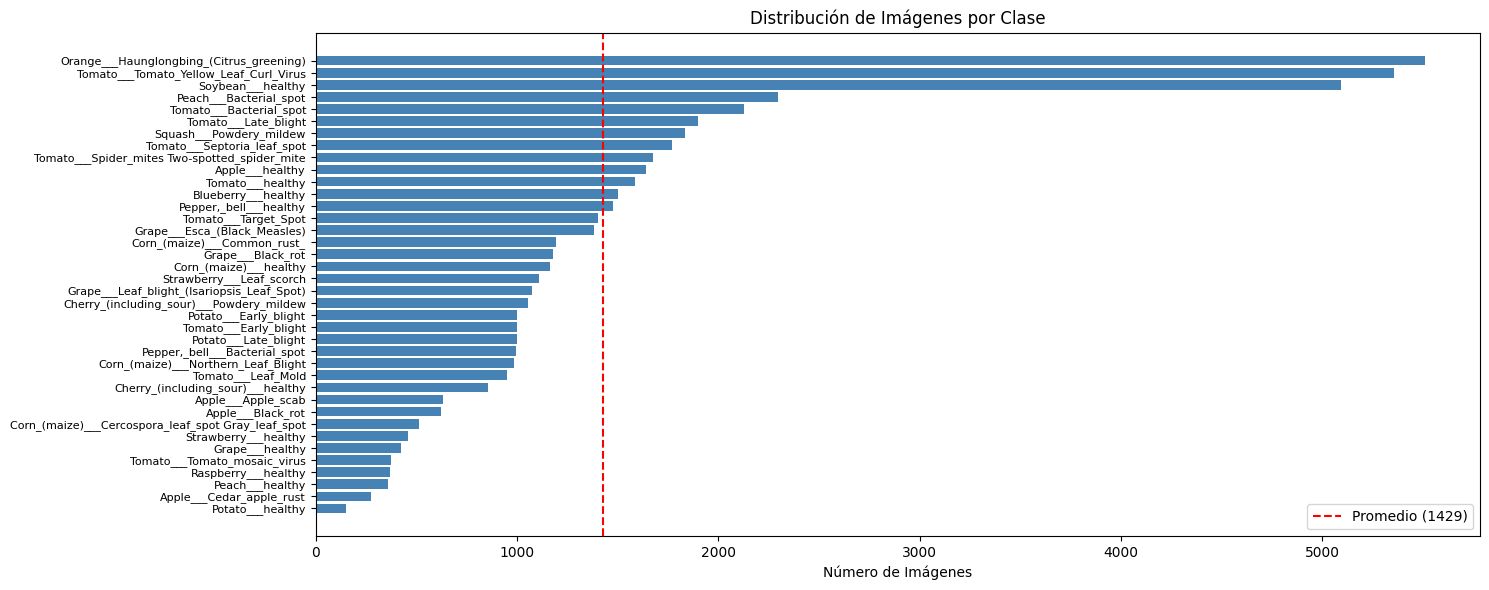


⚠️ Clases con representación baja (< 80% del promedio):
   20 clases requieren augmentation
   Potato___healthy                                  :   152 → necesita ~ 990 imágenes más
   Apple___Cedar_apple_rust                          :   275 → necesita ~ 867 imágenes más
   Peach___healthy                                   :   360 → necesita ~ 782 imágenes más
   Raspberry___healthy                               :   371 → necesita ~ 771 imágenes más
   Tomato___Tomato_mosaic_virus                      :   373 → necesita ~ 769 imágenes más
   Grape___healthy                                   :   423 → necesita ~ 719 imágenes más
   Strawberry___healthy                              :   456 → necesita ~ 686 imágenes más
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 → necesita ~ 629 imágenes más
   Apple___Black_rot                                 :   621 → necesita ~ 521 imágenes más
   Apple___Apple_scab                                :   630 → necesita ~ 512 imágenes m

In [ ]:
def analyze_class_distribution(data_dir):
    """
    Analiza la distribución de imágenes por clase.
    """
    class_counts = {}

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            img_files = [f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(img_files)

    return class_counts

print("="*70)
print("PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES")
print("="*70)

class_distribution = analyze_class_distribution(data_dir)
total_images = sum(class_distribution.values())
num_classes = len(class_distribution)

print(f"\n📊 Dataset Statistics:")
print(f"   Total de clases: {num_classes}")
print(f"   Total de imágenes: {total_images}")
print(f"   Promedio por clase: {total_images / num_classes:.1f}")

# Ordenar por cantidad de imágenes
sorted_classes = sorted(class_distribution.items(), key=lambda x: x[1])

print(f"\n📉 Top 10 clases con MENOS imágenes:")
for class_name, count in sorted_classes[:10]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

print(f"\n📈 Top 10 clases con MÁS imágenes:")
for class_name, count in sorted_classes[-10:]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

# Visualizar distribución
plt.figure(figsize=(15, 6))
classes_sorted = [c[0] for c in sorted_classes]
counts_sorted = [c[1] for c in sorted_classes]

plt.barh(range(len(classes_sorted)), counts_sorted, color='steelblue')
plt.yticks(range(len(classes_sorted)), classes_sorted, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(x=total_images/num_classes, color='red', linestyle='--',
            label=f'Promedio ({total_images/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()

# Identificar clases con menos representación (< 80% del promedio)
threshold = 0.8 * (total_images / num_classes)
underrepresented_classes = {c: count for c, count in class_distribution.items()
                           if count < threshold}

print(f"\n⚠️ Clases con representación baja (< 80% del promedio):")
print(f"   {len(underrepresented_classes)} clases requieren augmentation")
for class_name, count in sorted(underrepresented_classes.items(), key=lambda x: x[1]):
    needed = int(threshold - count)
    print(f"   {class_name:50s}: {count:5d} → necesita ~{needed:4d} imágenes más")


## 3. Data Augmentation para Clases Desbalanceadas

Aplicamos augmentation selectivo solo a las clases con menor representación.
Esto balancea el dataset sin sobre-aumentar las clases ya bien representadas.


In [ ]:
def create_augmentation_pipeline():
    """
    Crea un pipeline de augmentation. Se aplican: rotación de hasta 20 grados en amabas orientaciones;
    espejado de imagenes (horizontal y vertical); modificacion de brillo, contraste y saturación en un 20%;
    se mueve la imagen aleatoriamente en un 10% (horizontal y verticalmente); recorte aleatorio de entre un 80 y un 100%

    """
    return transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    ])

def augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8):
    """
    Aumenta las clases con menos representación hasta alcanzar un umbral objetivo.

    Args:
        data_dir: Directorio raíz del dataset
        class_distribution: Dict con {clase: cantidad}
        target_percentile: Percentil objetivo (0.8 = 80% del promedio)
    """
    total_images = sum(class_distribution.values())
    num_classes = len(class_distribution)
    target_count = int(target_percentile * (total_images / num_classes))

    augmentation = create_augmentation_pipeline()
    total_generated = 0

    print("="*70)
    print("PASO 3: DATA AUGMENTATION SELECTIVO")
    print("="*70)
    print(f"Objetivo: ~{target_count} imágenes por clase")

    for class_name, current_count in tqdm(class_distribution.items(), desc="Procesando clases"):
        if current_count >= target_count:
            continue  # Clase ya tiene suficientes imágenes

        needed = target_count - current_count
        class_path = os.path.join(data_dir, class_name)

        # Obtener todas las imágenes de esta clase
        img_files = [f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not img_files:
            continue

        # Generar data augmentation
        generated = 0
        while generated < needed:
            # Seleccionar imagen origen aleatoria
            source_img_name = np.random.choice(img_files)
            source_img_path = os.path.join(class_path, source_img_name)

            try:
                # Cargar y aumentar
                img = Image.open(source_img_path).convert('RGB')
                augmented_img = augmentation(img)

                # Guardar con nombre único
                base_name = os.path.splitext(source_img_name)[0]
                aug_name = f"{base_name}_aug_{generated}.jpg"
                aug_path = os.path.join(class_path, aug_name)

                augmented_img.save(aug_path)
                generated += 1
                total_generated += 1

            except Exception as e:
                print(f"Error augmentando {source_img_path}: {e}")
                continue

        print(f"  ✓ {class_name:50s}: +{generated} imágenes ({current_count} → {current_count + generated})")

    print(f"\n✅ Data Augmentation completado: {total_generated} nuevas imágenes generadas")

    return total_generated


PASO 3: DATA AUGMENTATION SELECTIVO
Objetivo: ~1142 imágenes por clase


Procesando clases:   3%|▎         | 1/38 [00:04<02:47,  4.53s/it]

  ✓ Apple___Cedar_apple_rust                          : +867 imágenes (275 → 1142)


Procesando clases:   5%|▌         | 2/38 [00:05<01:22,  2.29s/it]

  ✓ Potato___Late_blight                              : +142 imágenes (1000 → 1142)


...

  ✓ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)        : +66 imágenes (1076 → 1142)


Procesando clases:  89%|████████▉ | 34/38 [00:44<00:04,  1.23s/it]

  ✓ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: +629 imágenes (513 → 1142)


Procesando clases: 100%|██████████| 38/38 [00:47<00:00,  1.25s/it]

  ✓ Apple___Apple_scab                                : +512 imágenes (630 → 1142)

✅ Data Augmentation completado: 8641 nuevas imágenes generadas

DISTRIBUCIÓN DESPUÉS DE AUGMENTATION

📊 Nuevas estadísticas:
   Total de imágenes: 62925 (antes: 54284, +8641)
   Promedio por clase: 1655.9


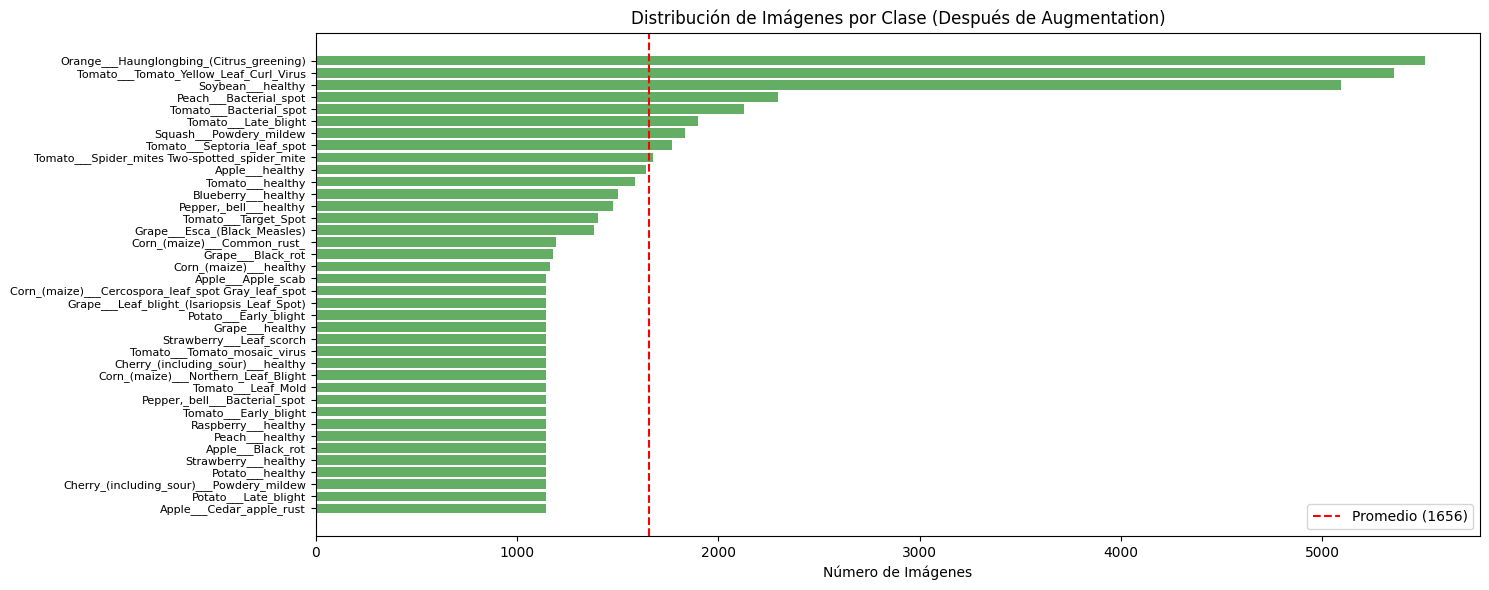

In [ ]:
# Ejecutar data augmentation
generated_images = augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8)

# Re-analizar distribución después del augmentation
print("\n" + "="*70)
print("DISTRIBUCIÓN DESPUÉS DE AUGMENTATION")
print("="*70)

new_distribution = analyze_class_distribution(data_dir)
new_total = sum(new_distribution.values())

print(f"\n📊 Nuevas estadísticas:")
print(f"   Total de imágenes: {new_total} (antes: {total_images}, +{new_total - total_images})")
print(f"   Promedio por clase: {new_total / num_classes:.1f}")

# Visualizar nueva distribución
plt.figure(figsize=(15, 6))
sorted_new = sorted(new_distribution.items(), key=lambda x: x[1])
classes_new = [c[0] for c in sorted_new]
counts_new = [c[1] for c in sorted_new]

plt.barh(range(len(classes_new)), counts_new, color='forestgreen', alpha=0.7)
plt.yticks(range(len(classes_new)), classes_new, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase (Después de Augmentation)')
plt.axvline(x=new_total/num_classes, color='red', linestyle='--',
            label=f'Promedio ({new_total/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Preparación de Datos y Transformaciones


In [ ]:
# Transformaciones para train (con augmentation adicional ligero)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones para val y test (sin augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


## 5. Partición Estratificada del Dataset


In [ ]:
def stratified_split_indices(indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=None):
    """
    Divide los índices de forma estratificada por clase.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    train_idxs, val_idxs, test_idxs = [], [], []

    # Agrupar por clase
    class_to_idxs = {}
    for i in indices:
        class_to_idxs.setdefault(labels[i], []).append(i)

    # Dividir cada clase
    for cls, idxs in class_to_idxs.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        n = len(idxs)

        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        train_idxs.extend(idxs[:n_train])
        val_idxs.extend(idxs[n_train:n_train + n_val])
        test_idxs.extend(idxs[n_train + n_val:])

    return train_idxs, val_idxs, test_idxs

# Cargar dataset completo
full_dataset = datasets.ImageFolder(root=data_dir)
labels = [label for _, label in full_dataset.samples]
num_classes = len(full_dataset.classes)

rng = np.random.RandomState(42)

if test_execution:
    # Subset reducido para pruebas
    subset_indices = []
    reduction_factor = 0.1

    for class_idx in range(num_classes):
        class_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == class_idx]
        n_samples = max(1, int(len(class_indices) * reduction_factor))
        chosen = rng.choice(class_indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    train_indices, val_indices, test_indices = stratified_split_indices(
        subset_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), train_indices)
    val_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=val_transform), val_indices)
    test_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=test_transform), test_indices)
else:
    # Dataset completo
    all_indices = list(range(len(full_dataset)))
    train_indices, val_indices, test_indices = stratified_split_indices(
        all_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    train_dataset = Subset(full_dataset, train_indices)
    val_dataset = Subset(full_dataset, val_indices)
    test_dataset = Subset(full_dataset, test_indices)

    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform
    test_dataset.dataset.transform = test_transform

print(f"✅ Dataset preparado:")
print(f"   Clases: {num_classes}")
print(f"   Train: {len(train_dataset)}")
print(f"   Val: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")


✅ Dataset preparado:
   Clases: 38
   Train: 50320
   Val: 6281
   Test: 6324


## 6. Funciones de Utilidad: Training y Evaluación


In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, patience=3, device='cuda'):
    """
    Entrena un modelo con early stopping.
    """
    since = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc_pr': [], 'val_auc_pr': []
    }

    model.to(device)
    best_metric = -np.inf
    counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_labels = []
            all_preds = []
            all_probs = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    probs = torch.softmax(outputs, dim=1)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

            all_probs = np.vstack(all_probs)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            auc_pr = average_precision_score(all_labels, all_probs, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} '
                  f'Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f} AUC-PR: {auc_pr:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                history['train_auc_pr'].append(auc_pr)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                history['val_auc_pr'].append(auc_pr)

        # Early stopping
        epoch_metric = history['val_f1'][-1]  # Usamos F1 como métrica principal

        if epoch_metric > best_metric:
            best_metric = epoch_metric
            counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    time_elapsed = time.time() - since
    print(f'\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor F1 validation: {best_metric:.4f}')

    # Cargar los mejores pesos
    model.load_state_dict(best_model_wts)

    return model, history, time_elapsed


def evaluate_model(model, dataloader, device='cpu'):
    """
    Evalúa un modelo en un conjunto de datos.
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    inference_time = time.time() - start_time
    all_probs = np.vstack(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc_pr = average_precision_score(all_labels, all_probs, average='macro')

    return accuracy, recall, f1, auc_pr, inference_time


def get_model_size(model, model_name="model"):
    """
    Calcula el tamaño del modelo en disco.
    """
    torch.save(model.state_dict(), f"{model_name}.pth")
    size_mb = os.path.getsize(f"{model_name}.pth") / 1e6
    os.remove(f"{model_name}.pth")
    return size_mb


def plot_history(history, title="Training History"):
    """
    Grafica las métricas de entrenamiento.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy'), ('recall', 'Recall'),
               ('f1', 'F1 Score'), ('auc_pr', 'AUC-PR')]

    for idx, (metric, label) in enumerate(metrics):
        row = idx // 3
        col = idx % 3

        axes[row, col].plot(history[f'train_{metric}'], label='Train', marker='o')
        axes[row, col].plot(history[f'val_{metric}'], label='Validation', marker='s')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(label)
        axes[row, col].set_title(f'{label} Over Time')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

    # Ocultar el último subplot vacío
    axes[1, 2].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


## Entrenamientos con hoperparámetros óptimos

### 8.1 Modelo 1: MobileNetV2 Optimizado


In [ ]:


# Definimos hiperparámetros básicos para los modelos
basic_hyperparams = {
    'lr': 0.01,
    'batch_size': 64,
    'num_epochs': 50,
    'patience': 5,
    'optimizer': 'SGD',
    'weight_decay': 0.0
}

# Crear dataloaders con el batch_size definido
optimal_batch_size = basic_hyperparams['batch_size']

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, shuffle=True,
                       num_workers=2, prefetch_factor=2),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=2, prefetch_factor=2),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                      num_workers=2, prefetch_factor=2)
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(train_dataset)} imágenes (100% del dataset)")
print(f"   Val: {len(val_dataset)} imágenes (100% del dataset)")
print(f"   Test: {len(test_dataset)} imágenes (100% del dataset)")

✅ Dataloaders creados con batch_size=64
   Train: 50320 imágenes (100% del dataset)
   Val: 6281 imágenes (100% del dataset)
   Test: 6324 imágenes (100% del dataset)


ENTRENANDO MODELO 1: MobileNetV2 Básico
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 205MB/s]


Epoch 1/50
----------
train Loss: 1.2434 Acc: 0.7798 Recall: 0.7241 F1: 0.7624 AUC-PR: 0.7959
val Loss: 0.5641 Acc: 0.9159 Recall: 0.8968 F1: 0.8997 AUC-PR: 0.9483
Epoch 2/50
----------
train Loss: 0.4635 Acc: 0.9257 Recall: 0.9095 F1: 0.9129 AUC-PR: 0.9553
val Loss: 0.3648 Acc: 0.9341 Recall: 0.9205 F1: 0.9226 AUC-PR: 0.9649
Epoch 3/50
----------
train Loss: 0.3349 Acc: 0.9394 Recall: 0.9272 F1: 0.9292 AUC-PR: 0.9681
val Loss: 0.2903 Acc: 0.9414 Recall: 0.9290 F1: 0.9311 AUC-PR: 0.9718
Epoch 4/50
----------
train Loss: 0.2764 Acc: 0.9473 Recall: 0.9369 F1: 0.9383 AUC-PR: 0.9742
val Loss: 0.2472 Acc: 0.9492 Recall: 0.9385 F1: 0.9400 AUC-PR: 0.9762
Epoch 5/50
----------
train Loss: 0.2423 Acc: 0.9514 Recall: 0.9416 F1: 0.9431 AUC-PR: 0.9775
val Loss: 0.2253 Acc: 0.9514 Recall: 0.9428 F1: 0.9426 AUC-PR: 0.9785
Epoch 6/50
----------
train Loss: 0.2186 Acc: 0.9544 Recall: 0.9455 F1: 0.9468 AUC-PR: 0.9800
val Loss: 0.2064 Acc: 0.9548 Recall: 0.9467 F1: 0.9468 AUC-PR: 0.9802
Epoch 7/50
-----

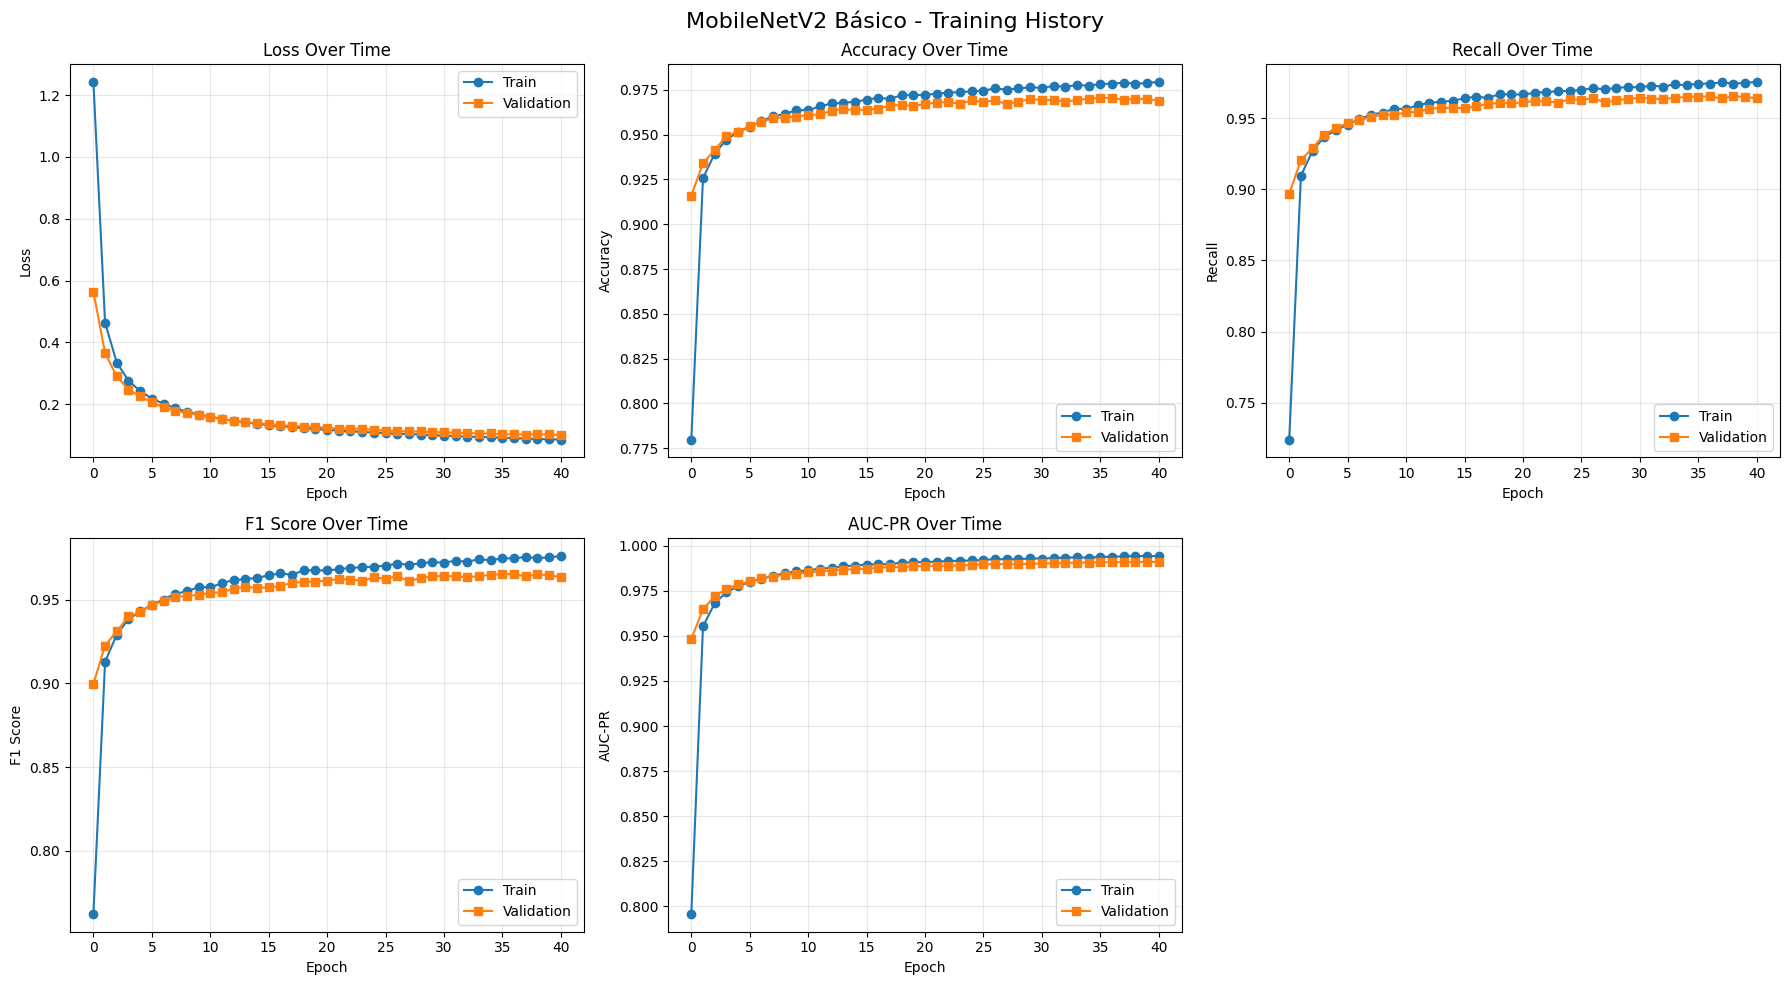

In [ ]:
print("="*70)
print("ENTRENANDO MODELO 1: MobileNetV2 Básico")
print("="*70)

# Cargar modelo preentrenado
model_v2_basic = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Congelar capas de features
for param in model_v2_basic.features.parameters():
    param.requires_grad = False

# Modificación del clasificador con una sola capa lineal
in_features = model_v2_basic.classifier[1].in_features
model_v2_basic.classifier = nn.Sequential(
    nn.Linear(in_features, num_classes)
)

# Definición de criterio y optimizador
criterion = nn.CrossEntropyLoss()
optimizer_v2 = optim.SGD(
    model_v2_basic.classifier.parameters(),
    lr=basic_hyperparams['lr'],
)

# Entrenamiento
model_v2_basic, hist_v2, time_v2 = train_model(
    model_v2_basic,
    dataloaders,
    criterion,
    optimizer_v2,
    num_epochs=basic_hyperparams['num_epochs'],
    patience=basic_hyperparams['patience'],
    device=device
)

# Visualizar resultados (usando plot_history ya definido en el notebook)
plot_history(hist_v2, title="MobileNetV2 Básico - Training History")


### 8.2 Modelo 2: MobileNetV3 Small



ENTRENANDO MODELO 2: MobileNetV3 Small Básico
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 218MB/s]

Epoch 1/50
----------


train Loss: 1.4651 Acc: 0.7085 Recall: 0.6367 F1: 0.6597 AUC-PR: 0.7065
val Loss: 0.6421 Acc: 0.8846 Recall: 0.8572 F1: 0.8620 AUC-PR: 0.9163
Epoch 2/50
----------
train Loss: 0.5152 Acc: 0.8939 Recall: 0.8727 F1: 0.8754 AUC-PR: 0.9251
val Loss: 0.3825 Acc: 0.9171 Recall: 0.9001 F1: 0.9014 AUC-PR: 0.9490
Epoch 3/50
----------
train Loss: 0.3622 Acc: 0.9140 Recall: 0.8981 F1: 0.8993 AUC-PR: 0.9486
val Loss: 0.3018 Acc: 0.9284 Recall: 0.9134 F1: 0.9145 AUC-PR: 0.9601
Epoch 4/50
----------
train Loss: 0.3003 Acc: 0.9249 Recall: 0.9113 F1: 0.9118 AUC-PR: 0.9582
val Loss: 0.2562 Acc: 0.9365 Recall: 0.9227 F1: 0.9241 AUC-PR: 0.9669
Epoch 5/50
----------
train Loss: 0.2639 Acc: 0.9307 Recall: 0.9182 F1: 0.9188 AUC-PR: 0.9643
val Loss: 0.2300 Acc: 0.9409 Recall: 0.9279 F1: 0.9294 AUC-PR: 0.9709
Epoch 6/50
----------
train Loss: 0.2382 Acc: 0.9359 Recall: 0.9245 F1: 0.9251 AUC-PR: 0.9681
val Loss: 0.2100 Acc: 0.9448 Recall: 0.9330 F1: 0.9337 AUC-PR: 0.9737
Epoch 7/50
----------
train Loss: 0.22

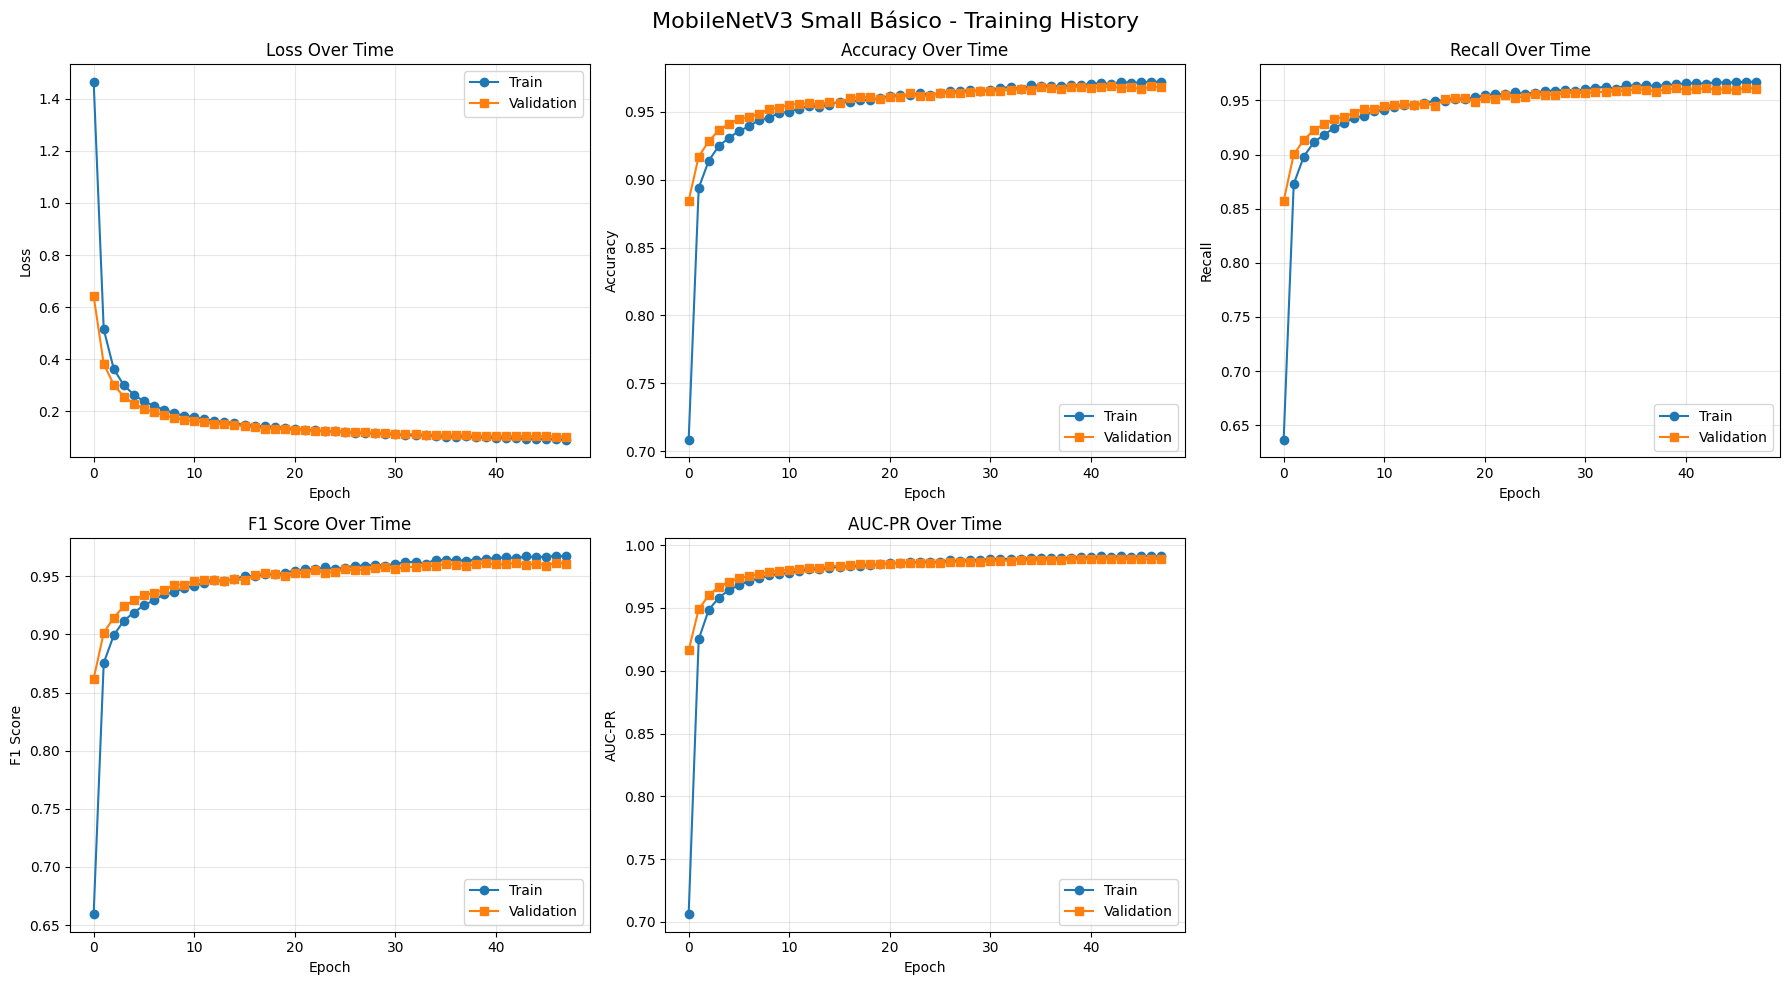

In [ ]:
print("\n" + "="*70)
print("ENTRENANDO MODELO 2: MobileNetV3 Small Básico")
print("="*70)

# Cargar modelo preentrenado "Small"
model_v3_basic = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Congelar capas de features
for param in model_v3_basic.features.parameters():
    param.requires_grad = False

# Modificación del clasificador con una sola capa lineal
in_features_v3 = model_v3_basic.classifier[3].in_features
model_v3_basic.classifier[3] = nn.Linear(in_features_v3, num_classes)

# Definición de criterio y optimizador
criterion = nn.CrossEntropyLoss()
optimizer_v3 = optim.SGD(
    model_v3_basic.classifier.parameters(),
    lr=basic_hyperparams['lr'],
)

# Entrenamiento
model_v3_basic, hist_v3, time_v3 = train_model(
    model_v3_basic,
    dataloaders,
    criterion,
    optimizer_v3,
    num_epochs=basic_hyperparams['num_epochs'],
    patience=basic_hyperparams['patience'],
    device=device
)

# Visualizar resultados (usando plot_history ya definido en el notebook)
plot_history(hist_v3, title="MobileNetV3 Small Básico - Training History")


## 9. Evaluación y Comparación de Modelos


In [ ]:
print("="*70)
print("EVALUACIÓN DE MODELOS EN TEST SET")
print("="*70)

# Evaluación de los modelos en CPU para comparación justa
print("\nEvaluando MobileNetV2 Básico...")
acc_v2, recall_v2, f1_v2, auc_pr_v2, inf_time_v2 = evaluate_model(model_v2_basic, dataloaders['test'], 'cpu')
size_v2 = get_model_size(model_v2_basic, "v2_basic_temp")

print("\nEvaluando MobileNetV3 Small Básico...")
acc_v3, recall_v3, f1_v3, auc_pr_v3, inf_time_v3 = evaluate_model(model_v3_basic, dataloaders['test'], 'cpu')
size_v3 = get_model_size(model_v3_basic, "v3_basic_temp")

# Creación de tabla de resultados
results = {
    'MobileNetV2 Básico': {
        'Accuracy': acc_v2,
        'Recall': recall_v2,
        'F1 Score': f1_v2,
        'AUC-PR': auc_pr_v2,
        'Size (MB)': size_v2,
        'Inference Time (s)': inf_time_v2
    },
    'MobileNetV3 Small Básico': {
        'Accuracy': acc_v3,
        'Recall': recall_v3,
        'F1 Score': f1_v3,
        'AUC-PR': auc_pr_v3,
        'Size (MB)': size_v3,
        'Inference Time (s)': inf_time_v3
    }
}

df_results = pd.DataFrame(results).T

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)
print(df_results.to_string())
print("="*70)

EVALUACIÓN DE MODELOS EN TEST SET

Evaluando MobileNetV2 Básico...

Evaluando MobileNetV3 Small Básico...

RESUMEN DE RESULTADOS
                          Accuracy    Recall  F1 Score    AUC-PR  Size (MB)  Inference Time (s)
MobileNetV2 Básico        0.974858  0.970650  0.970507  0.992058   9.332363          384.351237
MobileNetV3 Small Básico  0.966319  0.959155  0.959720  0.989754   6.359155           64.524365


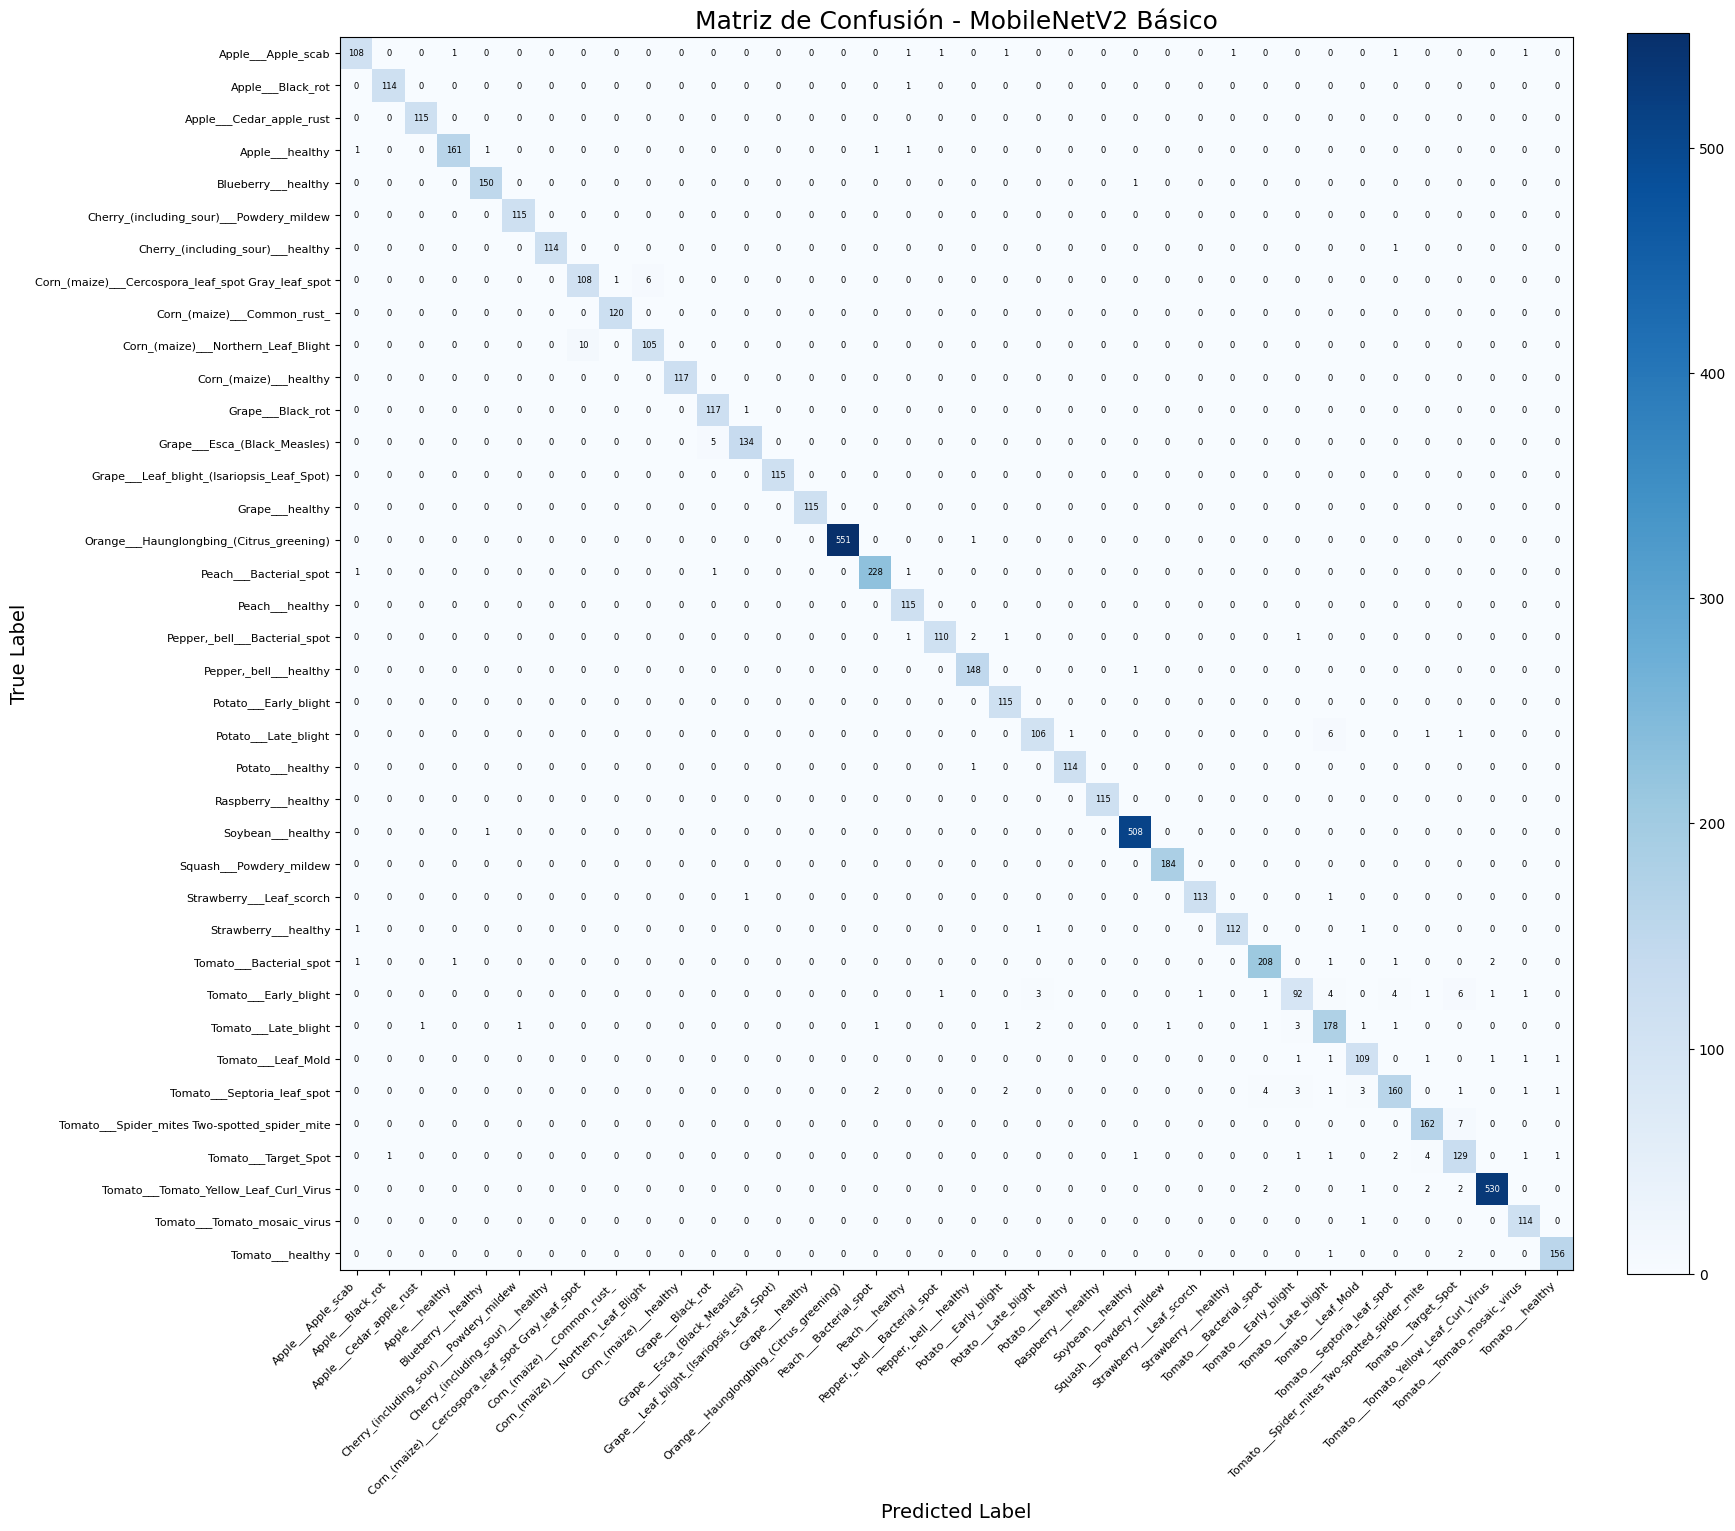

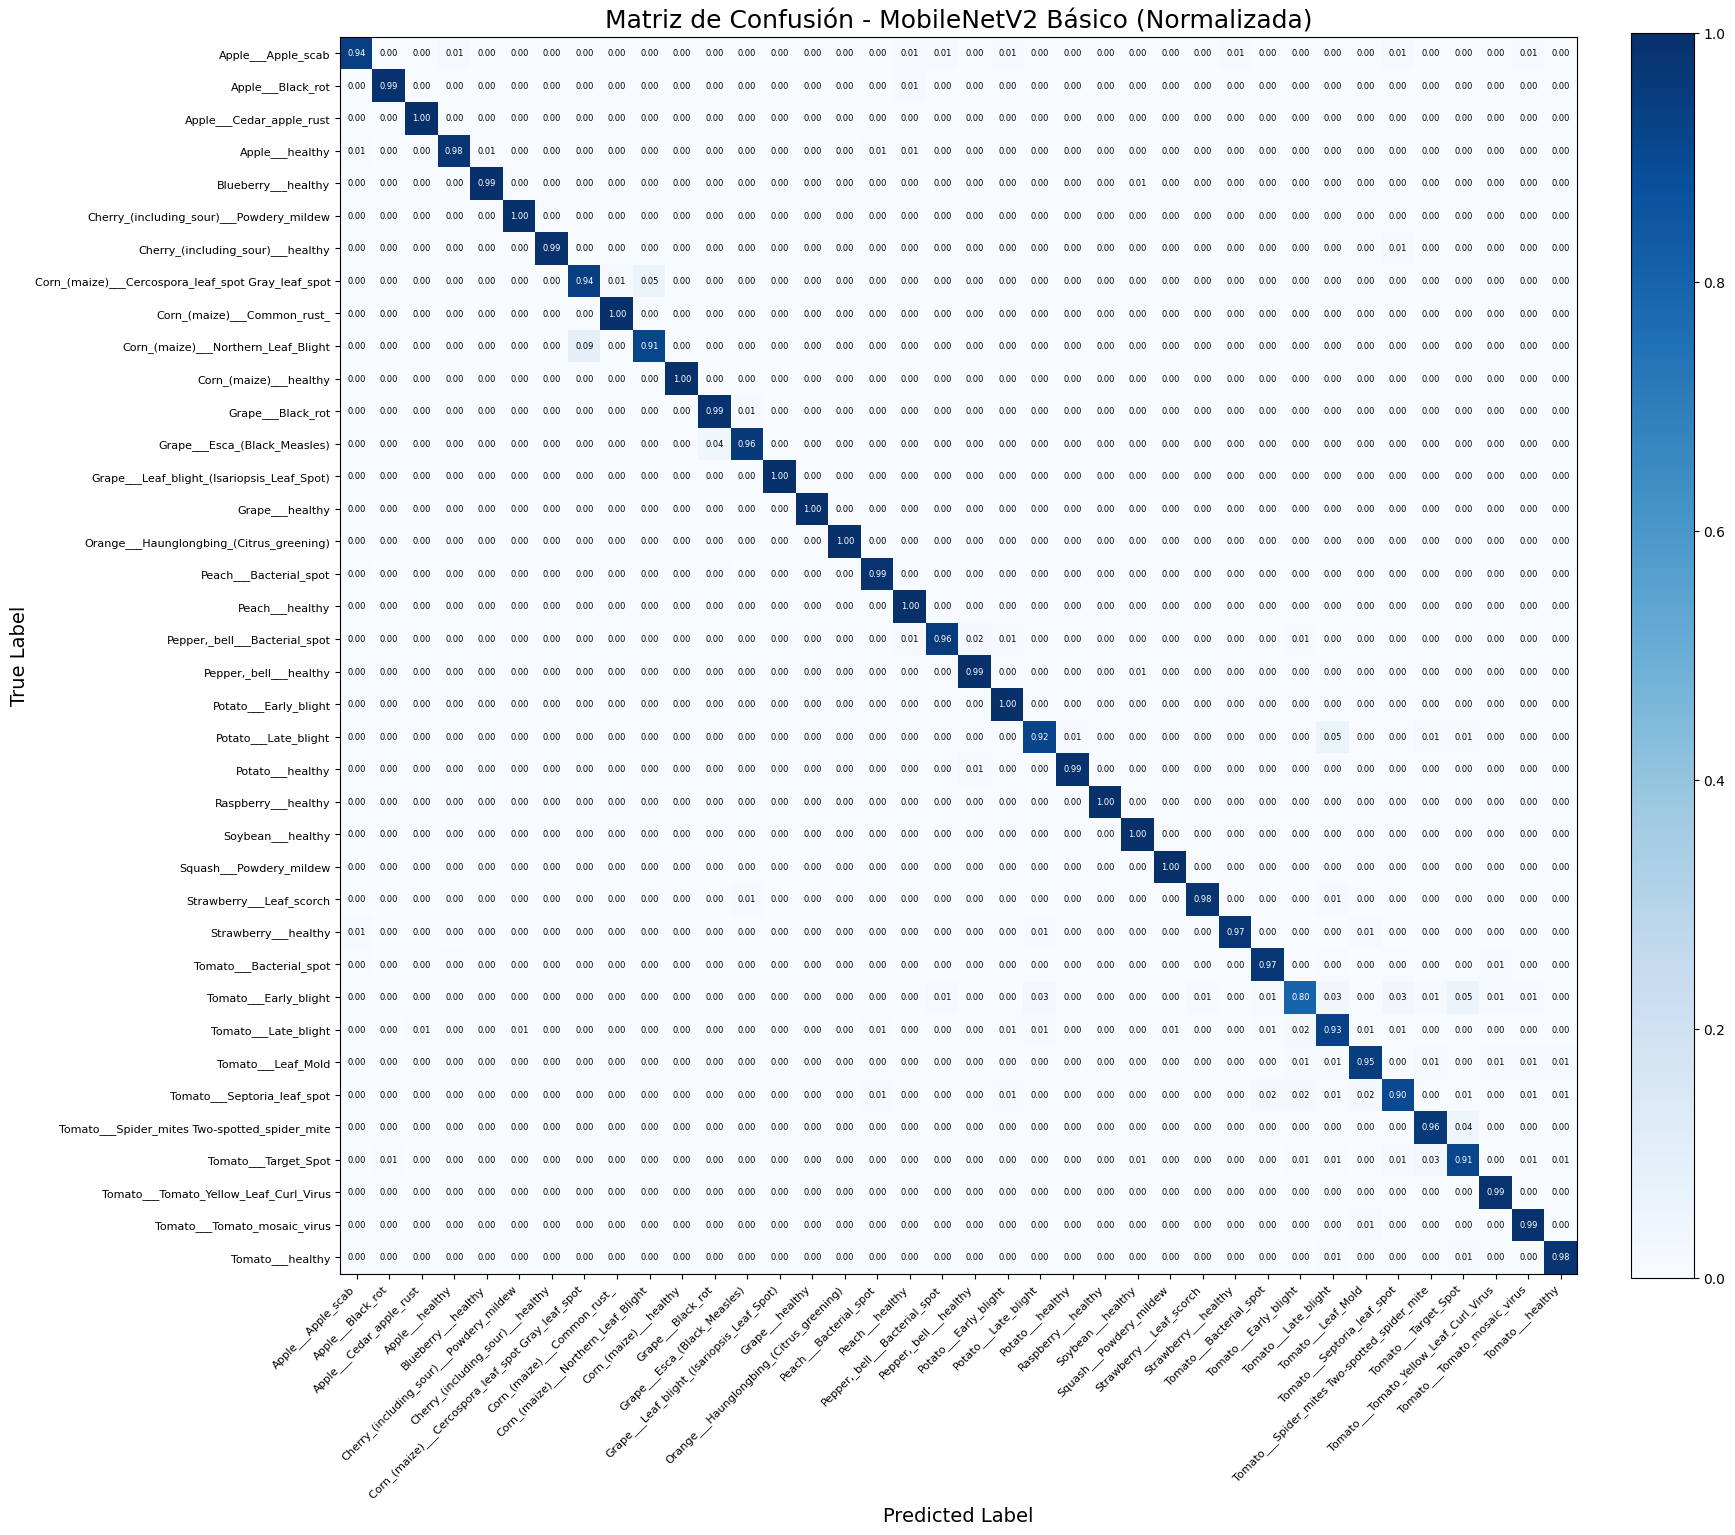

Overall Accuracy MobileNetV2 Básico: 0.9749
Recall Macro MobileNetV2 Básico: 0.9706

Classification Report MobileNetV2 Básico:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.94      0.95       115
                                 Apple___Black_rot       0.99      0.99      0.99       115
                          Apple___Cedar_apple_rust       0.99      1.00      1.00       115
                                   Apple___healthy       0.99      0.98      0.98       165
                               Blueberry___healthy       0.99      0.99      0.99       151
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      1.00       115
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.94      0.93       115
                       Corn_(maize)___Commo

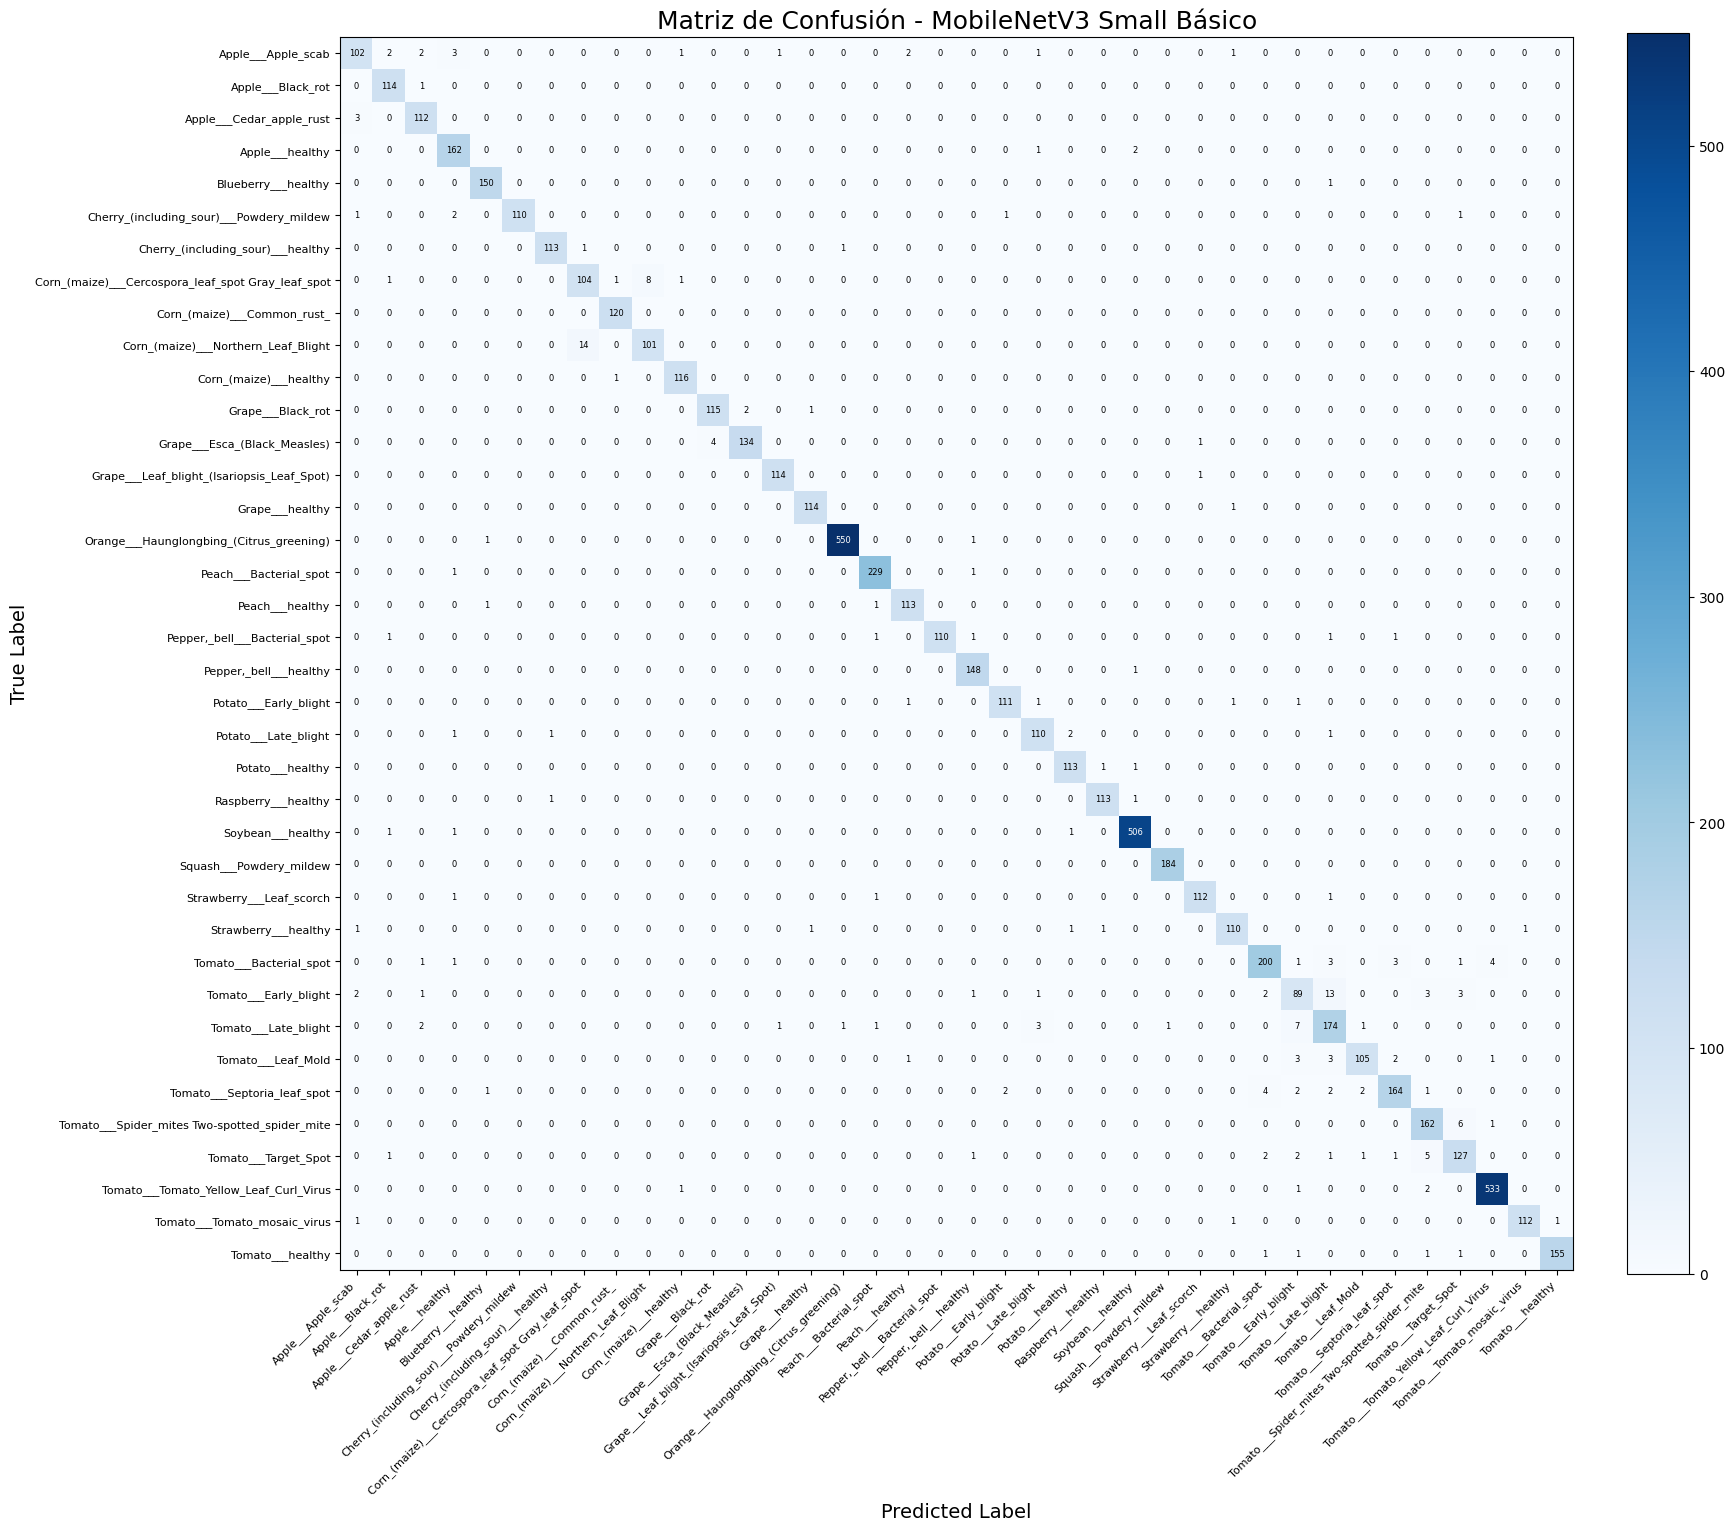

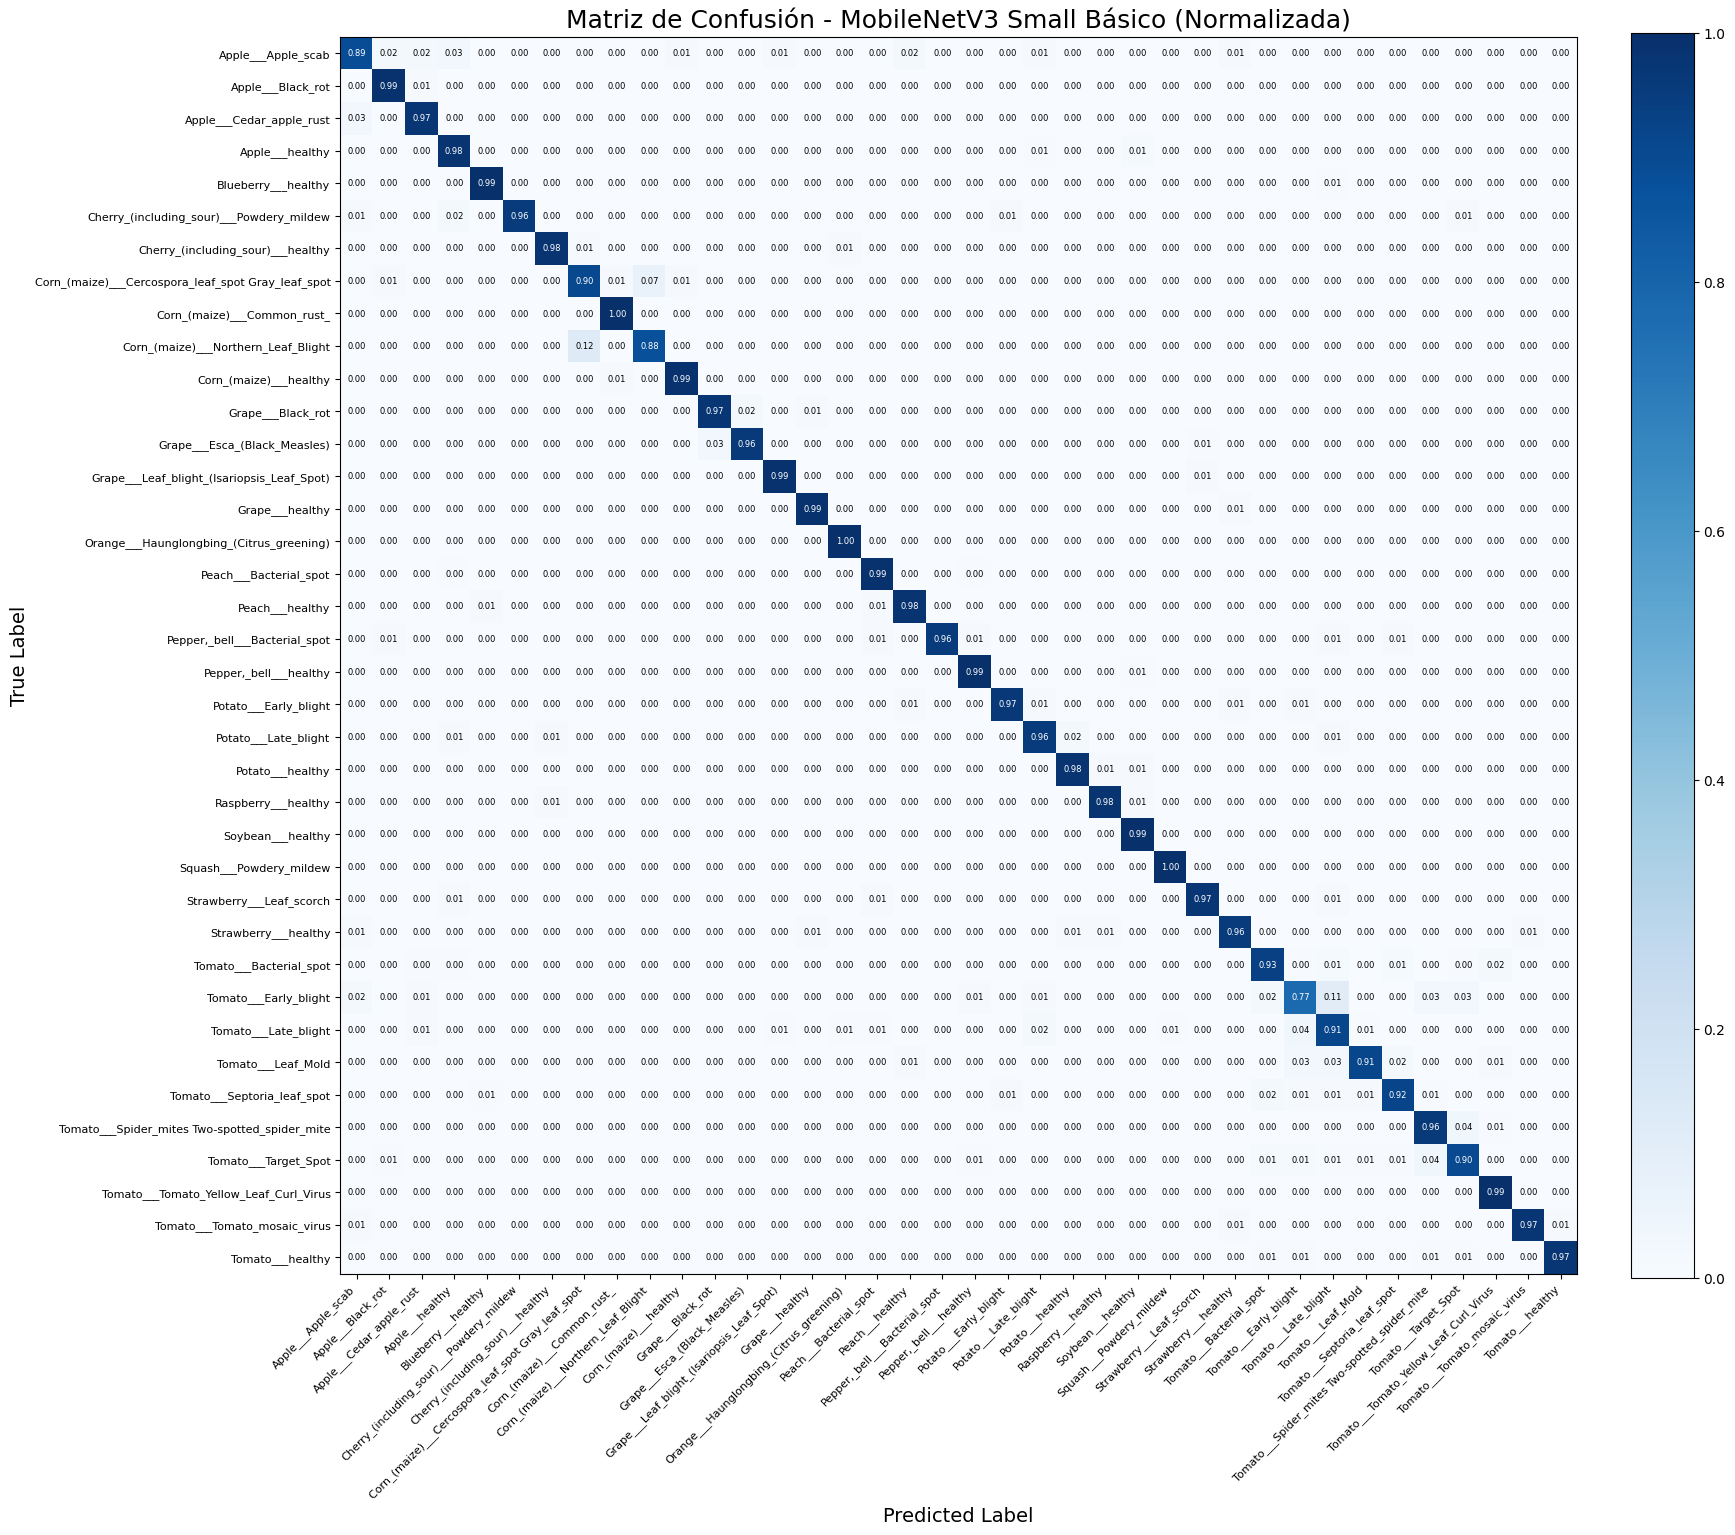

Overall Accuracy MobileNetV3 Small Básico: 0.9663
Recall Macro MobileNetV3 Small Básico: 0.9592

Classification Report MobileNetV3 Small Básico:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.89      0.91       115
                                 Apple___Black_rot       0.95      0.99      0.97       115
                          Apple___Cedar_apple_rust       0.94      0.97      0.96       115
                                   Apple___healthy       0.94      0.98      0.96       165
                               Blueberry___healthy       0.98      0.99      0.99       151
          Cherry_(including_sour)___Powdery_mildew       1.00      0.96      0.98       115
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.90      0.89       115
                       Co

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score

# --- Función para crear matriz de confusión y retornar predicciones y etiquetas ---
def create_confusion_matrix(model, dataloader, device='cpu'):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm, all_labels, all_preds

# --- Función para graficar matriz de confusión ---
def plot_cm(cm, classes, title, cmap=plt.cm.Blues, normalize=False):
    if normalize:
        cm_to_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        title += " (Normalizada)"
    else:
        cm_to_plot = cm
        fmt = 'd'

    plt.figure(figsize=(20, 20))
    plt.imshow(cm_to_plot, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=18)
    plt.colorbar(fraction=0.046, pad=0.04)

    thresh = cm_to_plot.max() / 2.
    for i in range(cm_to_plot.shape[0]):
        for j in range(cm_to_plot.shape[1]):
            plt.text(j, i, format(cm_to_plot[i, j], fmt),
                     horizontalalignment="center",
                     verticalalignment="center",
                     fontsize=6,
                     color="white" if cm_to_plot[i, j] > thresh else "black")

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(ticks=np.arange(len(classes)), labels=classes, rotation=45, ha='right', fontsize=8)
    plt.yticks(ticks=np.arange(len(classes)), labels=classes, fontsize=8)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3, left=0.3)
    plt.show()


# ------------------- MobileNetV2 -------------------
cm_v2, all_labels_v2, all_preds_v2 = create_confusion_matrix(model_v2_basic, dataloaders['test'], device='cpu')

# Grafico matriz de confusión
plot_cm(cm_v2, full_dataset.classes, "Matriz de Confusión - MobileNetV2 Básico")
plot_cm(cm_v2, full_dataset.classes, "Matriz de Confusión - MobileNetV2 Básico", normalize=True)

# Métricas y reporte
overall_acc_v2 = accuracy_score(all_labels_v2, all_preds_v2)
recall_macro_v2 = recall_score(all_labels_v2, all_preds_v2, average='macro', zero_division=0)
report_v2 = classification_report(all_labels_v2, all_preds_v2, target_names=full_dataset.classes, zero_division=0)

print(f"Overall Accuracy MobileNetV2 Básico: {overall_acc_v2:.4f}")
print(f"Recall Macro MobileNetV2 Básico: {recall_macro_v2:.4f}\n")
print("Classification Report MobileNetV2 Básico:\n")
print(report_v2)


# ------------------- MobileNetV3 -------------------
cm_v3, all_labels_v3, all_preds_v3 = create_confusion_matrix(model_v3_basic, dataloaders['test'], device='cpu')

# Grafico matriz de confusión
plot_cm(cm_v3, full_dataset.classes, "Matriz de Confusión - MobileNetV3 Small Básico")
plot_cm(cm_v3, full_dataset.classes, "Matriz de Confusión - MobileNetV3 Small Básico", normalize=True)

# Métricas y reporte
overall_acc_v3 = accuracy_score(all_labels_v3, all_preds_v3)
recall_macro_v3 = recall_score(all_labels_v3, all_preds_v3, average='macro', zero_division=0)
report_v3 = classification_report(all_labels_v3, all_preds_v3, target_names=full_dataset.classes, zero_division=0)

print(f"Overall Accuracy MobileNetV3 Small Básico: {overall_acc_v3:.4f}")
print(f"Recall Macro MobileNetV3 Small Básico: {recall_macro_v3:.4f}\n")
print("Classification Report MobileNetV3 Small Básico:\n")
print(report_v3)

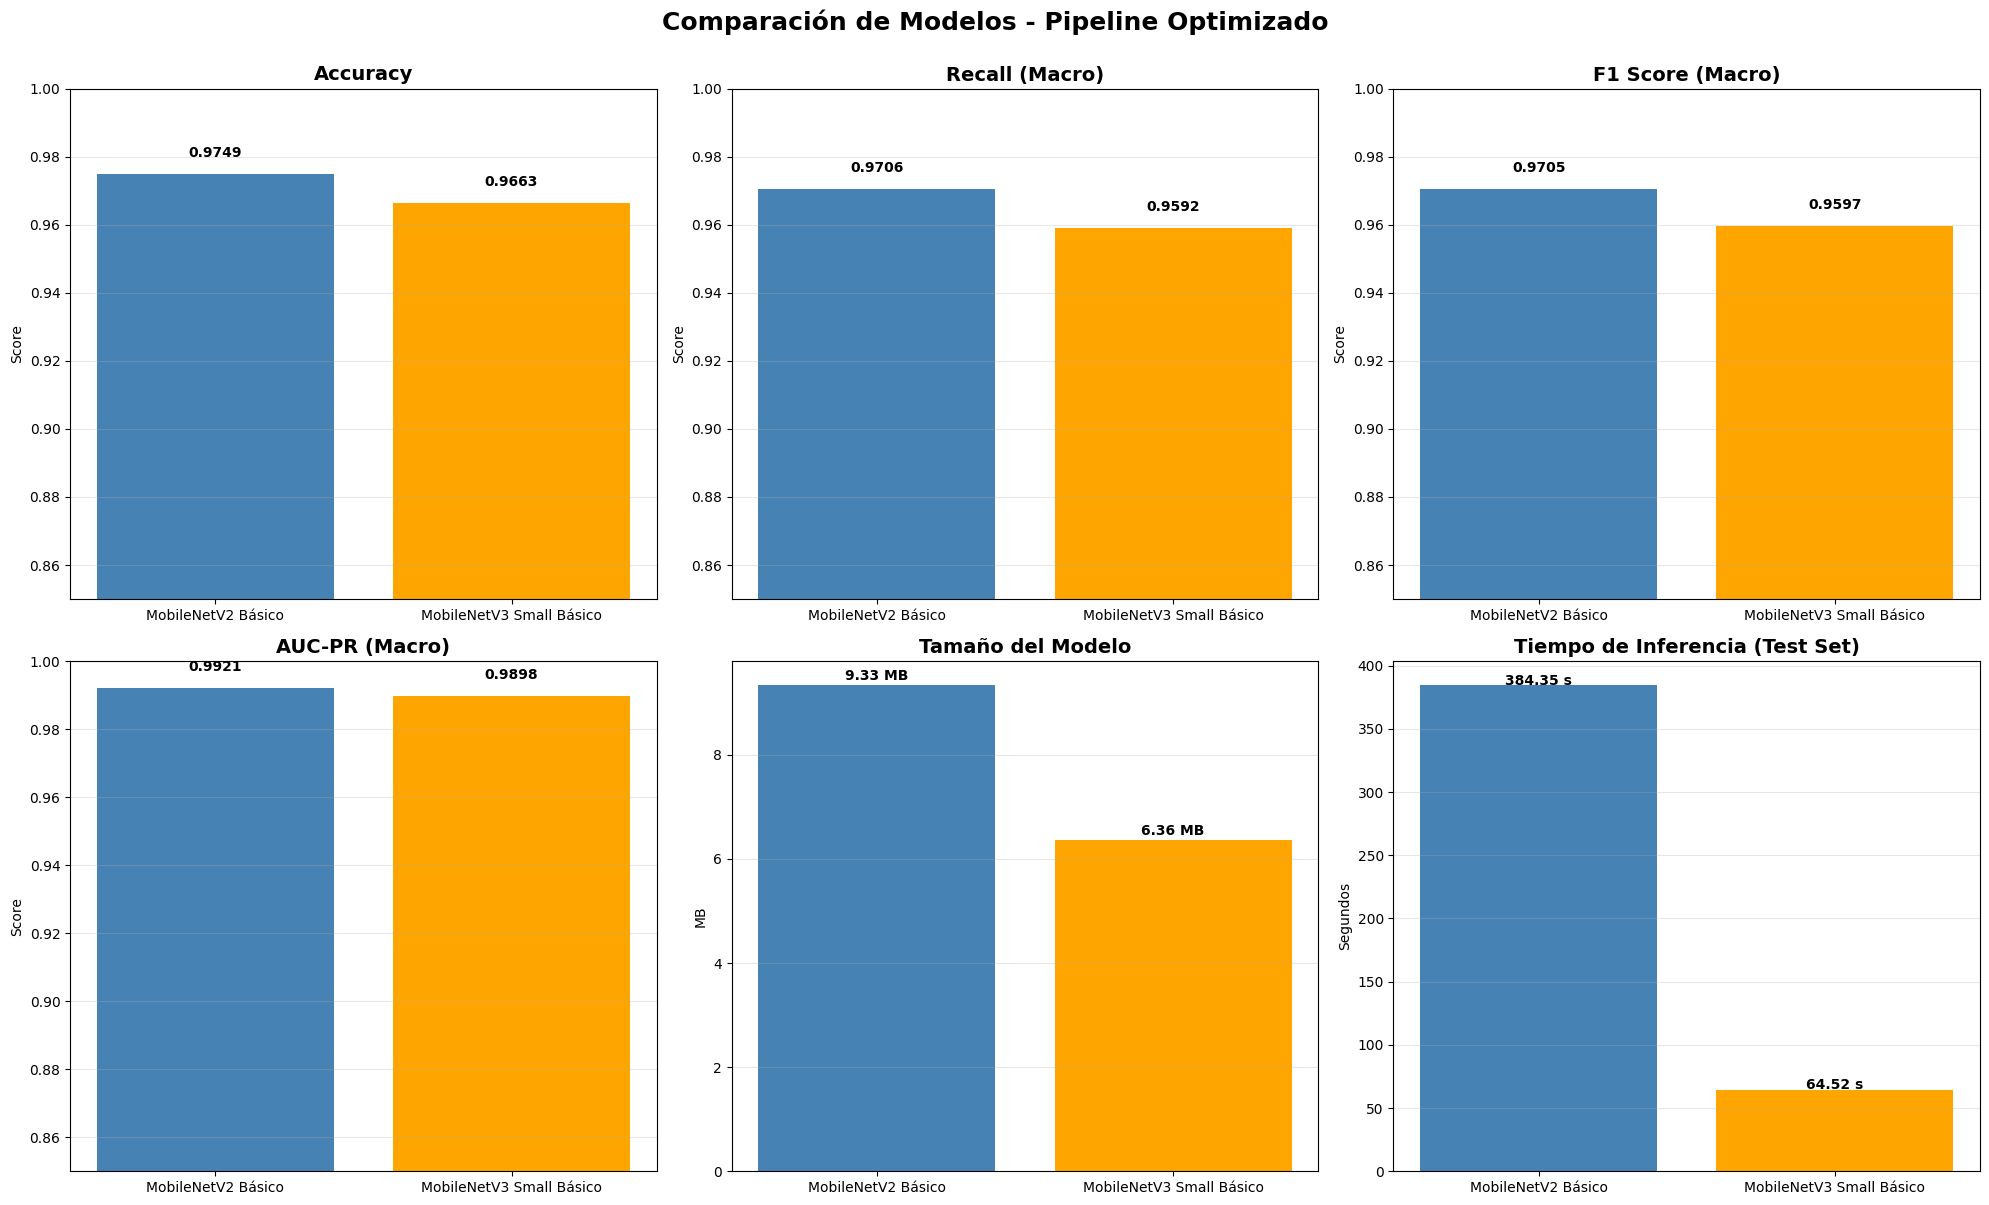

In [ ]:
# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = df_results.index.tolist()
colors = ['steelblue', 'orange', 'forestgreen']

# 1. Accuracy
axes[0, 0].bar(models_list, df_results['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0.85, 1.0)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Accuracy']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Recall
axes[0, 1].bar(models_list, df_results['Recall'], color=colors)
axes[0, 1].set_title('Recall (Macro)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Recall']):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. F1 Score
axes[0, 2].bar(models_list, df_results['F1 Score'], color=colors)
axes[0, 2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_ylim(0.85, 1.0)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['F1 Score']):
    axes[0, 2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 4. AUC-PR
axes[1, 0].bar(models_list, df_results['AUC-PR'], color=colors)
axes[1, 0].set_title('AUC-PR (Macro)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0.85, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['AUC-PR']):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Tamaño del modelo
axes[1, 1].bar(models_list, df_results['Size (MB)'], color=colors)
axes[1, 1].set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('MB')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Size (MB)']):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# 6. Tiempo de inferencia
axes[1, 2].bar(models_list, df_results['Inference Time (s)'], color=colors)
axes[1, 2].set_title('Tiempo de Inferencia (Test Set)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Segundos')
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Inference Time (s)']):
    axes[1, 2].text(i, v + 0.5, f'{v:.2f} s', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos - Pipeline Optimizado',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. Análisis de Mejoras

Comparamos el impacto de nuestras optimizaciones:


In [ ]:
print("="*70)
print("ANÁLISIS DE MEJORAS IMPLEMENTADAS Y RESULTADOS BÁSICOS")
print("="*70)

print("\n1️1. ELIMINACIÓN DE DUPLICADOS")
# Si 'duplicates' no se encontró (ej: test_execution=True y dataset pequeño sin duplicados), ajusta el mensaje.
print(f"   • Imágenes duplicadas eliminadas: {removed if 'removed' in locals() and duplicates else 0}")
print(f"   • Beneficio: Reduce overfitting y mejora generalización")

print("\n2️2. DATA AUGMENTATION SELECTIVO")
print(f"   • Imágenes sintéticas generadas: {generated_images}")
print(f"   • Clases balanceadas: {len(underrepresented_classes)}")
print(f"   • Beneficio: Mejora rendimiento en clases minoritarias")

print("\n3️3. CONFIGURACIÓN DE HIPERPARÁMETROS BÁSICA")
print("   • Se utilizaron hiperparámetros fijos para la comparación de modelos base, sin optimización con Optuna.")
print("   • Hiperparámetros usados:")
for key, value in basic_hyperparams.items():
    print(f"     - {key}: {value}")
print(f"   • Beneficio: Establecer una línea base de rendimiento para comparaciones futuras.")

print("\n4️4. RESULTADOS FINALES DE LOS MODELOS BÁSICOS")
print(f"   • Mejor modelo (precisión): {df_results['Accuracy'].idxmax()}")
print(f"     - Accuracy: {df_results['Accuracy'].max():.4f}")
print(f"     - Recall: {df_results.loc[df_results['Accuracy'].idxmax(), 'Recall']:.4f}")
print(f"     - F1 Score: {df_results.loc[df_results['Accuracy'].idxmax(), 'F1 Score']:.4f}")

print(f"\n   • Mejor modelo (tamaño): {df_results['Size (MB)'].idxmin()}")
print(f"     - Tamaño: {df_results['Size (MB)'].min():.2f} MB")
print(f"     - Accuracy: {df_results.loc[df_results['Size (MB)'].idxmin(), 'Accuracy']:.4f}")

print(f"\n   • Mejor modelo (velocidad): {df_results['Inference Time (s)'].idxmin()}")
print(f"     - Tiempo: {df_results['Inference Time (s)'].min():.2f} segundos")
print(f"     - Accuracy: {df_results.loc[df_results['Inference Time (s)'].idxmin(), 'Accuracy']:.4f}")

print("\n" + "="*70)


ANÁLISIS DE MEJORAS IMPLEMENTADAS Y RESULTADOS BÁSICOS

1️⃣ ELIMINACIÓN DE DUPLICADOS
   • Imágenes duplicadas eliminadas: 21
   • Beneficio: Reduce overfitting y mejora generalización

2️⃣ DATA AUGMENTATION SELECTIVO
   • Imágenes sintéticas generadas: 8641
   • Clases balanceadas: 20
   • Beneficio: Mejora rendimiento en clases minoritarias

3️⃣ CONFIGURACIÓN DE HIPERPARÁMETROS BÁSICA
   • Se utilizaron hiperparámetros fijos para la comparación de modelos base, sin optimización con Optuna.
   • Hiperparámetros usados:
     - lr: 0.01
     - batch_size: 64
     - num_epochs: 50
     - patience: 5
     - optimizer: SGD
     - weight_decay: 0.0
   • Beneficio: Establecer una línea base de rendimiento para comparaciones futuras.

4️⃣ RESULTADOS FINALES DE LOS MODELOS BÁSICOS
   • Mejor modelo (precisión): MobileNetV2 Básico
     - Accuracy: 0.9749
     - Recall: 0.9706
     - F1 Score: 0.9705

   • Mejor modelo (tamaño): MobileNetV3 Small Básico
     - Tamaño: 6.36 MB
     - Accuracy: 0.

## 11. Conclusiones y Recomendaciones

### Resumen de Optimizaciones Implementadas

**1. Eliminación de Duplicados**
- Detectamos y eliminamos imágenes duplicadas usando hashing.
- Esto reduce el sesgo de memorización y mejora la generalización del modelo
- El dataset resultante es más limpio y representativo

**2. Data Augmentation Inteligente**
- Aplicamos augmentation **solo** a las clases con representación inferior al 80% del promedio
- Generamos imágenes sintéticas con transformaciones realistas (rotación, flip, color jitter)
- Resultado: Dataset más balanceado sin sobre-aumentar clases ya bien representadas

### Comparación de Modelos

Los dos modelos entrenados muestran trade-offs diferentes:

**MobileNetV2 Optimizado:**
- Mejor accuracy y recall en general
- Modelo base robusto con hiperparámetros optimizados
- Mayor tamaño (~9 MB)
- Recomendado cuando la precisión es prioridad

**MobileNetV3 Small:**
- Excelente balance entre precisión y eficiencia
- ~50% más pequeño que V2
- Inferencia más rápida
- Recomendado para deployment móvil estándar


## 12. Guardar Modelos y Configuración

Guardamos los modelos entrenados y la configuración para uso posterior.


In [ ]:
# Guardar modelos
torch.save(model_v2_basic.state_dict(), 'mobilenetv2_basic.pth')
torch.save(model_v3_basic.state_dict(), 'mobilenetv3_small_basic.pth')

# Guardar hiperparámetros y resultados
import json

config = {
    'basic_hyperparameters': basic_hyperparams,
    'num_classes': num_classes,
    'class_names': full_dataset.classes,
    'results': results
}

with open('model_config_basic.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

print("✅ Modelos y configuración guardados:")
print("   - mobilenetv2_basic.pth")
print("   - mobilenetv3_small_basic.pth")
print("   - model_config_basic.json")

# Guardar resultados en CSV
df_results.to_csv('model_comparison_results_basic.csv')
print("   - model_comparison_results_basic.csv")


✅ Modelos y configuración guardados:
   - mobilenetv2_basic.pth
   - mobilenetv3_small_basic.pth
   - model_config_basic.json
   - model_comparison_results_basic.csv
